# Mini-Project: Multimodal Machine Learning on Glioblastoma Spatial Transcriptomics

**Net4Brain Training School**

Over three days you build a machine learning pipeline on human glioblastoma tissue. Work section by section: find the matching heading in `Demo_DLPFC.ipynb` and use the idea.

## Goal

Each tissue spot is either in the **tumour core** or in the **periphery**
surrounding it. Train a model to tell them apart from molecular data, then ask
which features it used and whether they make biological sense.

## Dataset

| **Tissue** | Human glioblastoma, IDH-wildtype |
|---|---|
| **Spots** | 35,187 tissue spots |
| **Patients** | 6 |
| **Sections** | 15 (2–5 per patient) |
| **Modality 1** | 2,000 highly variable genes — 10x Visium, **measured** |
| **Modality 2** | 168 metabolic module rates — scFEA, **inferred from the expression data** |
| **Label** | `Core` or `Periphery` |

## Change from the demo

| In the demo (DLPFC) | On your data (GBM) |
|---|---|
| `dlpfc_*.csv.gz` | `gbm_*.csv.gz` |
| `layer` | `region` |
| `donor` | `patient` |
| `sample_id` | `section` |
| `array_col`, `array_row` | `x`, `y` |
| Superficial / Deep | Core / Periphery |
| markers `MBP`, `MOBP`, `RELN` | markers `CHI3L1`, `VEGFA`, `NEFM` |

Your target is already in `df_meta["region"]`.

## How to use this notebook

Cells marked **TASK** are yours. Each one names the variables the rest of the
notebook expects. Do not delete the `# TODO` comments until you have replaced
them. If you get stuck, find the same section number in `Demo_DLPFC.ipynb` or ask tutors.

## A side note on the labels

`Periphery` is **not** healthy tissue. Glioblastoma infiltrates beyond its
visible core, so peripheral spots still contain tumour cells. The contrast is
*core versus surrounding tissue*, not *tumour versus normal*.

`Periphery` is also a merged class. The finer original annotation is in `region_detailed`.


> **This is the solution notebook** — the completed version of `Try_GBM.ipynb`.
> Every task cell is filled in. Use it to check your own work, or as a reference if you get stuck.


# Day 1: Introduction & Preparing Data

**Goal today:** Exploratory data analysis and preprocessing - know what is in your data before you model anything.


## 1.1 Setup


In [28]:
# On Google Colab, uncomment the next line once.
# !pip install -q scanpy shap


In [29]:
import os, urllib.request
import numpy as np
import pandas as pd
import scanpy as sc

sc.settings.verbosity = 1
print("Setup complete.")


Setup complete.


## 1.2 Download the data

Three tables, all describing the same spots in the same row order. That shared
index is what makes this multimodal. This download is about 48 MB.


In [30]:
DATA_DIR = "dataset"
BASE_URL = "https://raw.githubusercontent.com/Kaveh8/Workshop_Net4Brain/main/dataset"

FILES = ["gbm_gene_expression.csv.gz",
         "gbm_flux.csv.gz",
         "gbm_metadata.csv.gz",
         "scfea_module_info.csv"]

os.makedirs(DATA_DIR, exist_ok=True)
for fname in FILES:
    dest = os.path.join(DATA_DIR, fname)
    if os.path.exists(dest):
        print(f"already present: {fname}")
        continue
    print(f"downloading {fname} ...", end=" ", flush=True)
    urllib.request.urlretrieve(f"{BASE_URL}/{fname}", dest)
    print(f"{os.path.getsize(dest)/1e6:.1f} MB")


already present: gbm_gene_expression.csv.gz
already present: gbm_flux.csv.gz
already present: gbm_metadata.csv.gz
already present: scfea_module_info.csv


## 1.3 TASK — load the three tables

Create `df_gene`, `df_flux`, `df_meta`. All three files are gzipped CSVs with
the spot ID in the first column, so they need `index_col=0`.

Then check that the three tables share the same row index. If the rows were in
different orders, every later result would be silently wrong.


In [31]:
df_gene = pd.read_csv(f"{DATA_DIR}/gbm_gene_expression.csv.gz", index_col=0)
df_flux = pd.read_csv(f"{DATA_DIR}/gbm_flux.csv.gz", index_col=0)
df_meta = pd.read_csv(f"{DATA_DIR}/gbm_metadata.csv.gz", index_col=0)

print("gene expression :", df_gene.shape, " (spots x genes)")
print("metabolic flux  :", df_flux.shape, " (spots x modules)")
print("metadata        :", df_meta.shape, " (spots x descriptors)")
print("same spot IDs:", df_gene.index.equals(df_meta.index) and df_flux.index.equals(df_meta.index))


gene expression : (35187, 2000)  (spots x genes)
metabolic flux  : (35187, 168)  (spots x modules)
metadata        : (35187, 6)  (spots x descriptors)
same spot IDs: True


### What is actually in each table?

Print the first few rows. Are the values on the scale you expect? Are there
obvious missing values? Do the column names look like gene symbols and module IDs?

Expression values are already **log-normalised** — do not run `sc.pp.normalize`
or `sc.pp.log1p`.


In [32]:
print("GENE EXPRESSION — log-normalised counts, one column per gene")
display(df_gene.iloc[:4, :6])

print("METABOLIC FLUX — one column per scFEA module")
display(df_flux.iloc[:4, :6])

print("METADATA")
display(df_meta.head(4))

print("missing values:", int(df_gene.isna().sum().sum() + df_flux.isna().sum().sum()))
print("expression range: %.2f to %.2f" % (df_gene.values.min(), df_gene.values.max()))


GENE EXPRESSION — log-normalised counts, one column per gene


,AARS,AATK,ABAT,ABCA1,ABCA8,ABCC5
spot,,,,,,
AAACAACGAATAGTTC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,1.45,1.69,1.45,1.45,0.00,0.0
AAACAATCTACTAGCA-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,0.00,0.00,1.45,0.00,0.00,0.0
AAACACCAATAACTGC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,0.00,1.32,0.00,1.48,1.32,0.0
AAACAGAGCGACTCCT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,1.38,1.38,0.00,1.38,0.00,0.0


METABOLIC FLUX — one column per scFEA module


,M_1,M_2,M_3,M_4,M_5,M_6
spot,,,,,,
AAACAACGAATAGTTC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,0.00722,0.02154,0.01266,0.00126,0.00186,0.00203
AAACAATCTACTAGCA-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,0.00786,0.01131,0.01278,0.00123,0.00071,0.00203
AAACACCAATAACTGC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,0.00705,0.01821,0.01353,0.00084,0.00058,0.00203
AAACAGAGCGACTCCT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,0.01632,0.03248,0.02287,0.00241,0.00063,0.00203


METADATA


,patient,section,x,y,region,region_detailed
spot,,,,,,
AAACAACGAATAGTTC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU16,SNU16A,540.0,323.0,Periphery,LE_WM
AAACAATCTACTAGCA-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU16,SNU16A,567.0,320.0,Periphery,IT
AAACACCAATAACTGC-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU16,SNU16A,543.0,264.0,Periphery,LE_WM
AAACAGAGCGACTCCT-1_1_1_1_1_1_1_1_1_1_1_1_1_1_1,SNU16,SNU16A,618.0,309.0,Periphery,LE_WM


missing values: 0
expression range: 0.00 to 3.32


Your metadata columns:

- `region`: `Core` or `Periphery`. This is what you are predicting.
- `region_detailed`: the finer original annotation that `region` was merged from.
- `patient`: which of the 6 patients. This matters on Day 2.
- `section`: which of the 15 tissue sections.
- `x`, `y`: the spot's position in the tissue.


### Where the fluxomic data come from

The experiment is Visium, and the only molecule assayed at each spot is mRNA. The
flux table was computed from the gene expression by
[scFEA](https://github.com/changwn/scFEA), which we ran before the workshop.

Human central metabolism is written as a graph. scFEA collapses it into **168
modules** and predicts one flux per module per spot from the genes encoding
those enzymes. Say **"inferred flux"**, never "measured flux". A gene and a
flux module appearing together near the top of a ranking is one piece of
evidence, not two.


## 1.4 TASK — pack the tables into AnnData

Copy the pattern from Demo 1.4. The only changes are the coordinate columns:
use `x` and `y` instead of `array_col` and `array_row`, and flip `y` so the
tissue is not upside-down.


In [33]:
adata = sc.AnnData(df_gene, obs=df_meta.copy())
adata.obsm["spatial"] = np.column_stack([adata.obs["x"], -adata.obs["y"]])

adata_flux = sc.AnnData(df_flux, obs=adata.obs.copy())
adata_flux.obsm["spatial"] = adata.obsm["spatial"]

print(adata)
print(adata_flux)


AnnData object with n_obs × n_vars = 35187 × 2000
    obs: 'patient', 'section', 'x', 'y', 'region', 'region_detailed'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 35187 × 168
    obs: 'patient', 'section', 'x', 'y', 'region', 'region_detailed'
    obsm: 'spatial'


## 1.5 Exploratory data analysis


### TASK — how much data do you have?

Bar plots of spots per region, spots per patient, and sections per patient.


<Axes: title={'center': 'Sections per patient'}, xlabel='patient'>

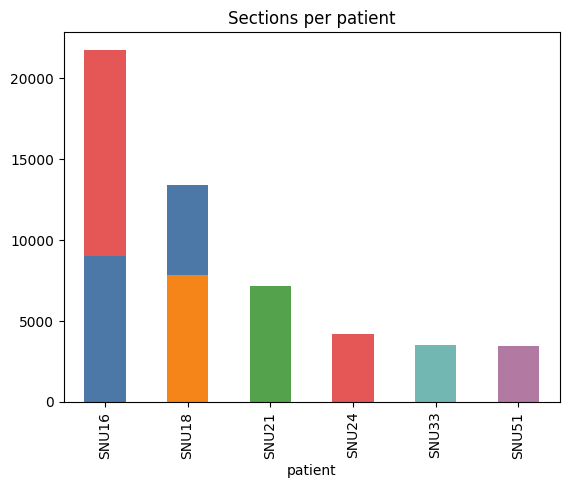

In [34]:
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]
adata.obs["region"].value_counts().plot.bar(color=["#E45756", "#4C78A8"], title="Spots per region")
adata.obs["patient"].value_counts().plot.bar(color=colors, title="Spots per patient")
adata.obs.groupby("patient")["section"].nunique().plot.bar(color="#72B7B2", title="Sections per patient")


### TASK — what does the tissue look like?

Plot one section, coloured by `region` (Demo 1.5).


/opt/homebrew/lib/python3.11/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/homebrew/lib/python3.11/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/homebrew/lib/python3.11/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/homebrew/lib/python3.11/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


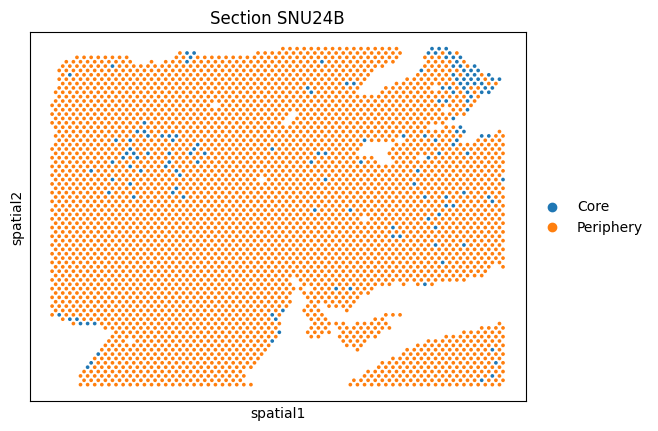

In [35]:
sec = adata.obs["section"].value_counts().index[0]
sub = adata[adata.obs["section"] == sec]
sc.pl.embedding(sub, basis="spatial", color="region", title=f"Section {sec}")


### TASK — marker genes

Violin and spatial plots of `CHI3L1`, `VEGFA`, `NEFM` (Demo 1.5).
`CHI3L1` and `VEGFA` should be higher in Core; `NEFM` in Periphery.


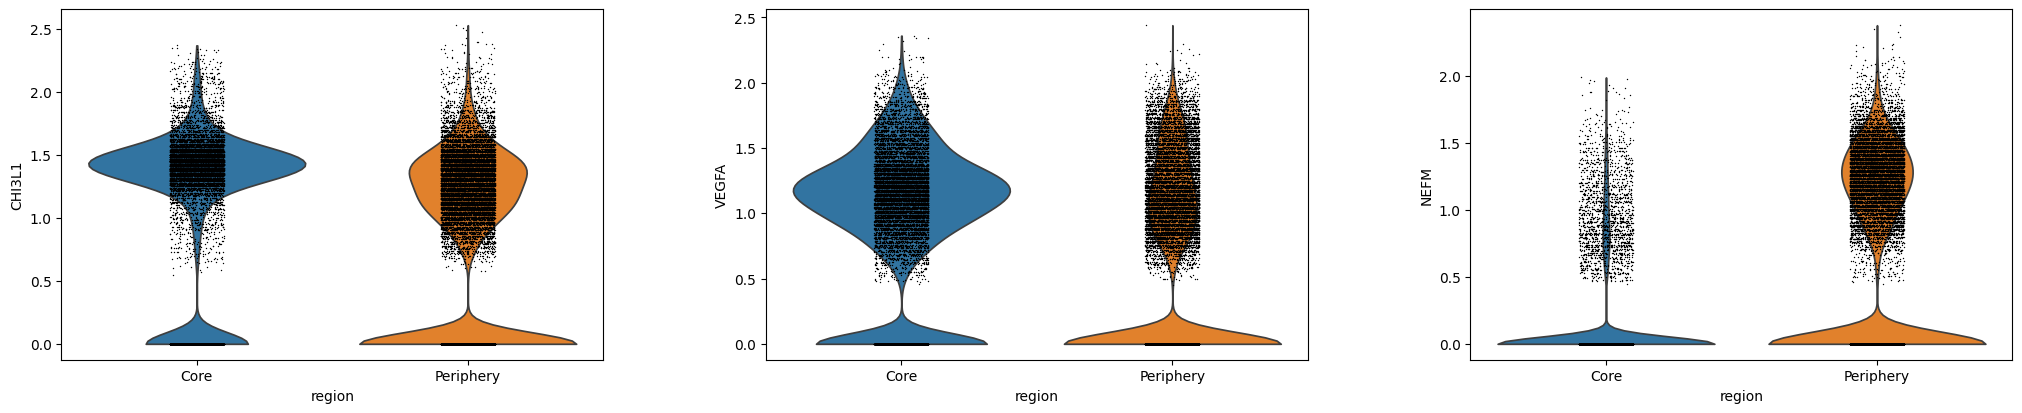

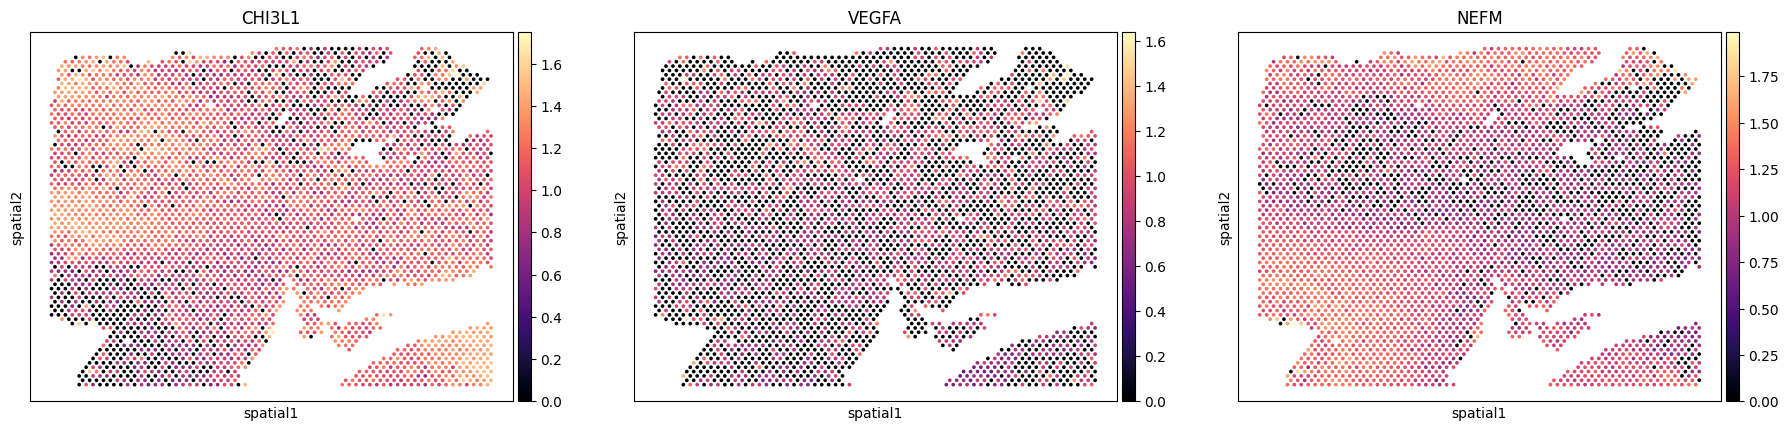

In [36]:
markers = ["CHI3L1", "VEGFA", "NEFM"]
sc.pl.violin(adata, markers, groupby="region")
sc.pl.embedding(sub, basis="spatial", color=markers, cmap="magma")


### TASK — metabolic modules

Pick a few module IDs and plot them the same way as the genes (Demo 1.5).


     Compound_IN_name Compound_OUT_name
M_2               G6P               G3P
M_3               G3P               3PD
M_25      Glutathione         glutamate


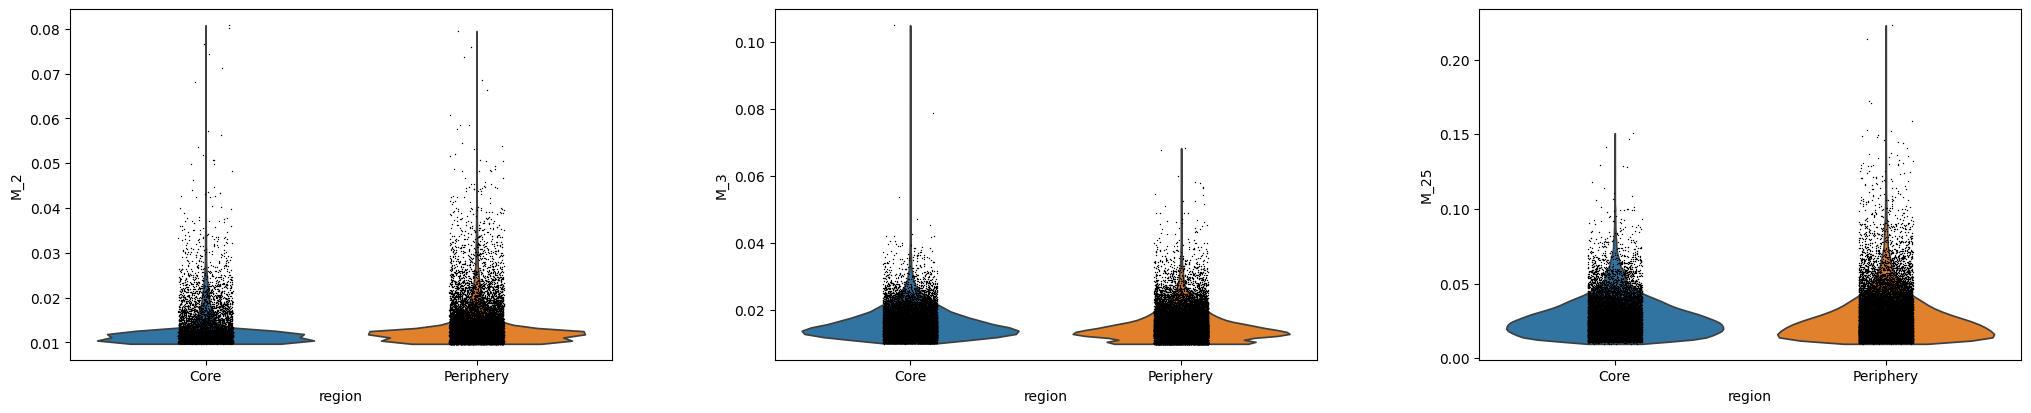

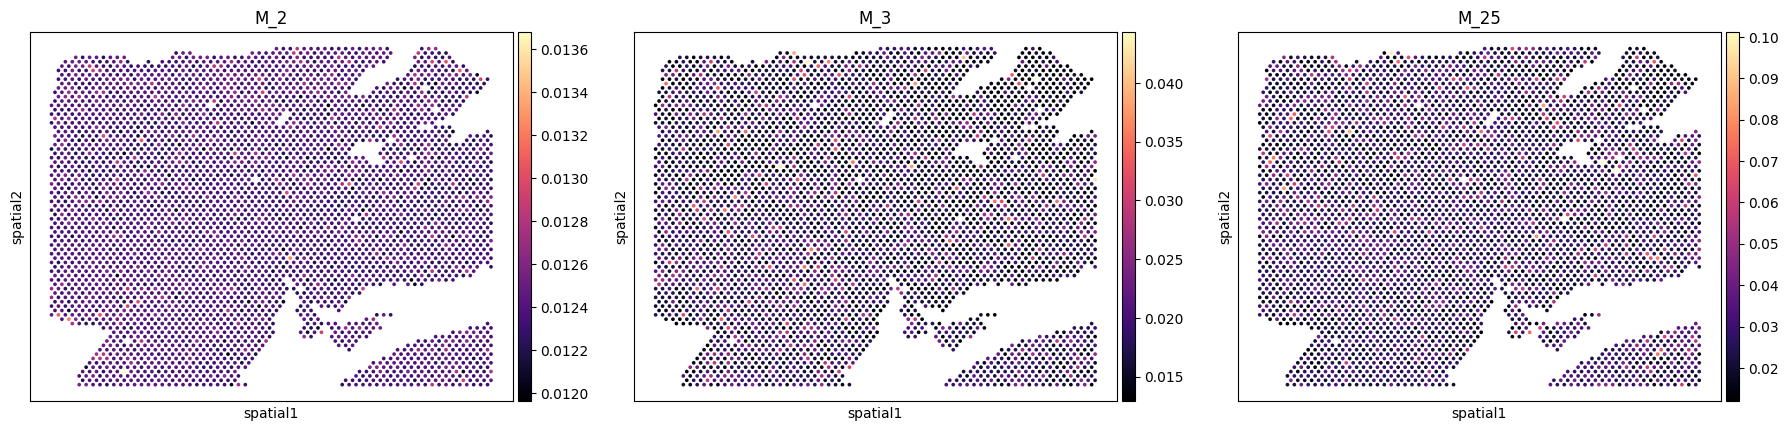

In [37]:
mod_info = pd.read_csv(f"{DATA_DIR}/scfea_module_info.csv", index_col=0)
mods = ["M_2", "M_3", "M_25"]
print(mod_info.loc[mods, ["Compound_IN_name", "Compound_OUT_name"]])

sc.pl.violin(adata_flux, mods, groupby="region")
sc.pl.embedding(adata_flux[adata_flux.obs["section"] == sec],
                basis="spatial", color=mods, cmap="magma")


## 1.6 TASK — labels

Your label is already in `region`. Set `y` and `groups` (Demo 1.6, without the layer merge).


In [38]:
y = adata.obs["region"]
groups = adata.obs["patient"]
print(y.value_counts().to_dict())
print("patients:", sorted(groups.unique()))


{'Periphery': 21768, 'Core': 13419}
patients: ['SNU16', 'SNU18', 'SNU21', 'SNU24', 'SNU33', 'SNU51']


---
# Day 2: Training models



In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


## 2.1 TASK — train / test split

Hold out one whole patient, as in Demo 2.1.


In [40]:
held_out = sorted(groups.unique())[0]
train = groups != held_out
test = groups == held_out

print("held-out patient:", held_out)
print("train spots:", int(train.sum()), "  test spots:", int(test.sum()))


held-out patient: SNU16
train spots: 31014   test spots: 4173


## 2.2 TASK — train a classifier

Scale, fit `LogisticRegression` on `df_gene`, predict the test spots (Demo 2.2).


In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(df_gene.loc[train])
X_test = scaler.transform(df_gene.loc[test])

model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y[train])
pred = model.predict(X_test)


## 2.3 TASK — classification results

Accuracy, classification report, and confusion matrix (Demo 2.3).


accuracy: 0.751

              precision    recall  f1-score   support

        Core       0.41      0.82      0.55       769
   Periphery       0.95      0.74      0.83      3404

    accuracy                           0.75      4173
   macro avg       0.68      0.78      0.69      4173
weighted avg       0.85      0.75      0.78      4173



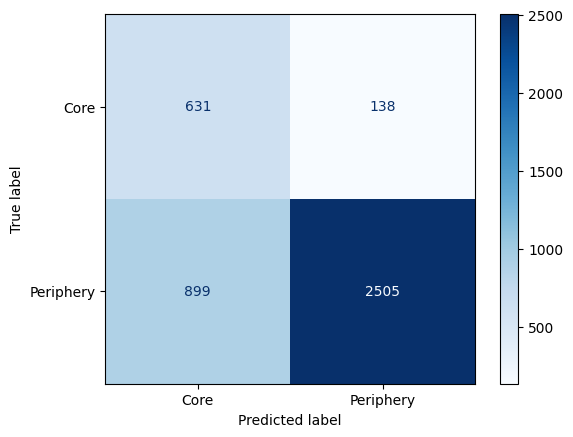

In [42]:
print("accuracy:", round(accuracy_score(y[test], pred), 3))
print()
print(classification_report(y[test], pred))
ConfusionMatrixDisplay.from_predictions(y[test], pred, cmap="Blues")


## 2.4 TASK — compare modalities

Train the same classifier on genes, flux, and both (Demo 2.4). Then fit the fused model and keep it for Day 3.


Gene expression    0.751
Metabolic flux     0.691
Both               0.779
dtype: float64
classes: ['Core', 'Periphery']


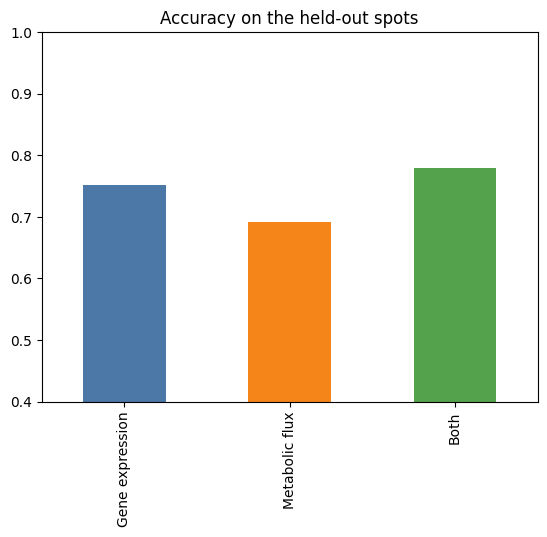

In [43]:
X_fused = pd.concat([df_gene, df_flux], axis=1)
X_fused = X_fused.loc[:, X_fused.loc[train].std() > 1e-5]

scores = {}
for name, X in [("Gene expression", df_gene),
                ("Metabolic flux", df_flux.loc[:, df_flux.loc[train].std() > 1e-5]),
                ("Both", X_fused)]:
    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(scaler.fit_transform(X.loc[train]), y[train])
    pred = clf.predict(scaler.transform(X.loc[test]))
    scores[name] = accuracy_score(y[test], pred)

print(pd.Series(scores).round(3))
pd.Series(scores).plot.bar(ylim=(0.4, 1.0), color=["#4C78A8", "#F58518", "#54A24B"],
                           title="Accuracy on the held-out spots")

# keep the fused model for Day 3
X = X_fused
scaler = StandardScaler()
X_train = scaler.fit_transform(X.loc[train])
X_test = scaler.transform(X.loc[test])
feat_names = X.columns
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y[train])
print("classes:", list(model.classes_))


---
# Day 3: Explainable AI


## 3.1 TASK — SHAP

The default SHAP summary (beeswarm) plot. See Demo 3.1.


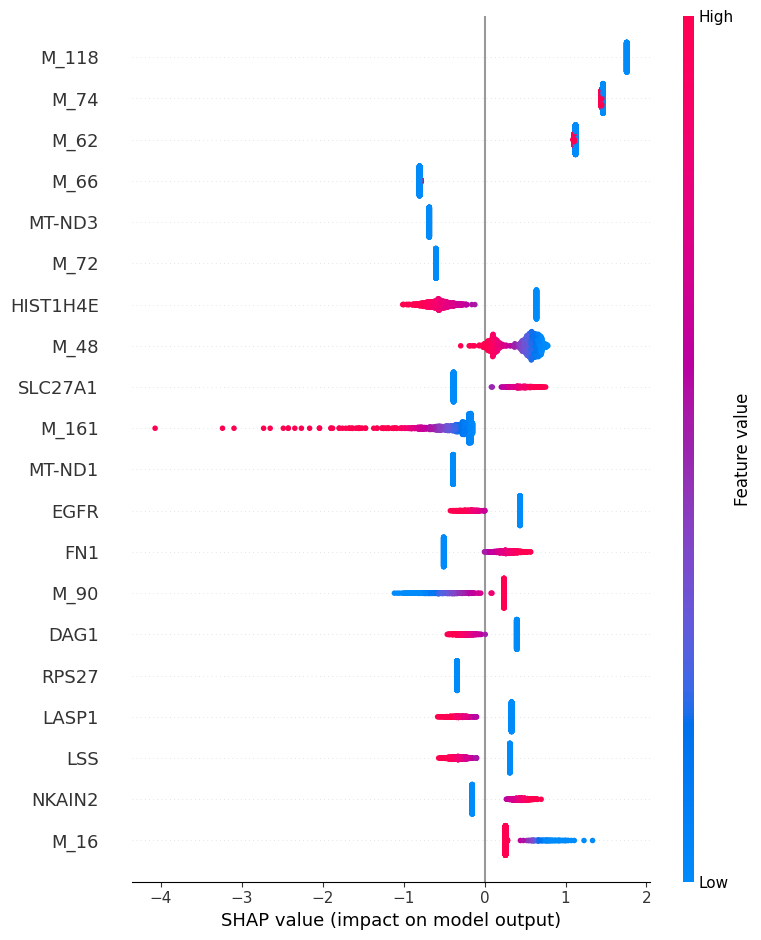

In [44]:
import shap

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test[:1000])
shap.summary_plot(shap_values, X_test[:1000], feature_names=list(feat_names))


## 3.2 TASK — logistic coefficients

The 15 largest coefficients, as a table and a bar plot (Demo 3.2).


positive class: Periphery (positive coefficient pushes toward this class)

M_74        1.778320
M_62        1.493876
MT-ND3      1.064904
M_118       0.976432
MT-ND1      0.593740
HIST1H4E    0.519924
M_72        0.493121
RPS27       0.488893
MT-ND2      0.481874
M_81        0.471282
M_17        0.464994
M_151       0.458618
M_66        0.448962
MT-CYB      0.417624
MT-ATP6     0.417400
Name: |coefficient|, dtype: float64


<Axes: title={'center': 'Largest logistic coefficients'}>

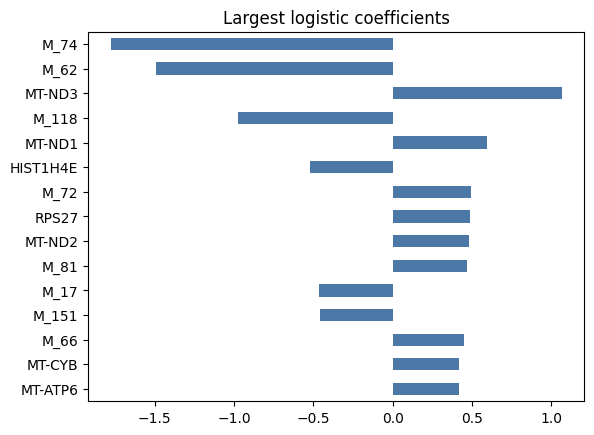

In [45]:
coef = pd.Series(model.coef_[0], index=feat_names)
print("positive class:", model.classes_[1], "(positive coefficient pushes toward this class)")
print()
print(coef.abs().sort_values(ascending=False).head(15).rename("|coefficient|"))

top = coef.reindex(coef.abs().sort_values(ascending=False).head(15).index)
top.iloc[::-1].plot.barh(color="#4C78A8", title="Largest logistic coefficients")


## How the flux values were generated

The flux tables are **not measured**. They were computed from the gene-expression
counts with [scFEA](https://github.com/changwn/scFEA) before the workshop. You
do not need to run this. It is here so you can see how the second modality
was produced.

```bash
git clone https://github.com/changwn/scFEA.git

# input: a genes x spots raw count matrix as CSV
python src/scFEA.py \
  --input_dir  <dir containing the count matrix> \
  --test_file  <counts.csv> \
  --moduleGene_file       module_gene_m168.csv \
  --stoichiometry_matrix  cmMat_c70_m168.csv \
  --cName_file            cName_c70_m168.csv \
  --sc_imputation True \
  --train_epoch 30 \
  --output_flux_file      <flux.csv>
```

`module_gene_m168.csv` maps genes to modules; `cmMat_c70_m168.csv` is the
stoichiometry matrix (70 compounds × 168 modules). The human M168 module set
was used for both datasets.
